## Section 1: Setup

In [2]:
import os

print("===== INPUT DATASETS =====")

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if files:
        print("  Files:", files[:10], "..." if len(files) > 10 else "")
    print()

===== INPUT DATASETS =====
/kaggle/input

/kaggle/input/datasets

/kaggle/input/datasets/sxmsxmsxm

/kaggle/input/datasets/sxmsxmsxm/phase5-outputs

/kaggle/input/datasets/sxmsxmsxm/phase5-outputs/checkpoints
  Files: ['audio_mlp_checkpoint.pt', 'phase5_unimodal_results.txt', 'text_mlp_checkpoint.pt', 'phase5_training_curves.png'] 

/kaggle/input/datasets/sxmsxmsxm/phase5-outputs/intermediate_features
  Files: ['train_labels.npy', 'test_labels.npy', 'train_audio_features.npy', 'test_text_features.npy', 'dev_audio_features.npy', 'dev_text_features.npy', 'train_text_features.npy', 'train_participant_ids.json', 'dev_labels.npy', 'test_audio_features.npy'] ...

/kaggle/input/datasets/sxmsxmsxm/phase5-outputs/text_embeddings_joint
  Files: ['422.npy', '331.npy', '461.npy', '375.npy', '308.npy', '330.npy', '464.npy', '407.npy', '491.npy', '489.npy'] ...



In [3]:
import os, json
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, classification_report
)
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PHASE5_DIR = "/kaggle/input/datasets/sxmsxmsxm/phase5-outputs"

CHECKPOINTS_DIR = os.path.join(PHASE5_DIR, "checkpoints")
FEATURES_DIR = os.path.join(PHASE5_DIR, "intermediate_features")

OUTPUT_DIR = "/kaggle/working/phase6_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_SEEDS = 5
N_BOOTSTRAP = 1000
N_EPOCHS = 60
PATIENCE = 10
RANDOM_SEED = 42

print("\ncheckpoints/:")
for f in sorted(os.listdir(CHECKPOINTS_DIR)):
    print(" ", f)
print("\nintermediate_features/:")
for f in sorted(os.listdir(FEATURES_DIR)):
    print(" ", f)

Using device: cpu

checkpoints/:
  audio_mlp_checkpoint.pt
  phase5_training_curves.png
  phase5_unimodal_results.txt
  text_mlp_checkpoint.pt

intermediate_features/:
  dev_audio_features.npy
  dev_labels.npy
  dev_participant_ids.json
  dev_text_features.npy
  test_audio_features.npy
  test_labels.npy
  test_participant_ids.json
  test_text_features.npy
  train_audio_features.npy
  train_labels.npy
  train_participant_ids.json
  train_text_features.npy


In [4]:
def load_split_features(split_name):
    text_X = np.load(os.path.join(FEATURES_DIR, f"{split_name}_text_features.npy"))
    audio_X = np.load(os.path.join(FEATURES_DIR, f"{split_name}_audio_features.npy"))
    y = np.load(os.path.join(FEATURES_DIR, f"{split_name}_labels.npy")).astype(int)
    with open(os.path.join(FEATURES_DIR, f"{split_name}_participant_ids.json")) as f:
        pids = json.load(f)
    assert len(text_X) == len(audio_X) == len(y) == len(pids), f"{split_name}: length mismatch across arrays!"
    return text_X, audio_X, y, pids


train_text_X, train_audio_X, train_y, train_pids = load_split_features("train")
dev_text_X, dev_audio_X, dev_y, dev_pids = load_split_features("dev")
test_text_X, test_audio_X, test_y, test_pids = load_split_features("test")

print(f"train: {len(train_y)} participants ({train_y.sum()} depressed)")
print(f"dev:   {len(dev_y)} participants ({dev_y.sum()} depressed)")
print(f"test:  {len(test_y)} participants ({test_y.sum()} depressed)")
print(f"\nFeature dims -- text: {train_text_X.shape[1]}, audio: {train_audio_X.shape[1]}")

train: 107 participants (30 depressed)
dev:   33 participants (12 depressed)
test:  47 participants (14 depressed)

Feature dims -- text: 128, audio: 128


In [5]:
ckpt = torch.load(
    os.path.join(CHECKPOINTS_DIR, "text_mlp_checkpoint.pt"),
    map_location="cpu",
    weights_only=False
)

print(ckpt.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'dev_macro_f1', 'dev_accuracy', 'input_dim'])


In [6]:
class DepressionMLP(nn.Module):
    '''Must match Phase 5's class EXACTLY for checkpoint loading to work.'''
    def __init__(self, input_dim=768, hidden_dim=256, feature_dim=128, dropout_rate=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
        )
        self.aux_head = nn.Linear(feature_dim, 1)

    def forward(self, x):
        features = self.encoder(x)
        logits = self.aux_head(features).squeeze(-1)
        return logits, features


def load_unimodal_model(ckpt_path):
    model = DepressionMLP(input_dim=768).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model


def unimodal_predict_proba(model, features_128dim):
    '''Apply ONLY aux_head to already-extracted 128-dim features -- reproduces
    Phase 5 own standalone prediction without re-running the encoder.'''
    model.eval()
    with torch.no_grad():
        feat_t = torch.tensor(features_128dim, dtype=torch.float32).to(device)
        logits = model.aux_head(feat_t).squeeze(-1)
        prob = torch.sigmoid(logits).cpu().numpy()
    return prob


text_model = load_unimodal_model(os.path.join(CHECKPOINTS_DIR, "text_mlp_checkpoint.pt"))
audio_model = load_unimodal_model(os.path.join(CHECKPOINTS_DIR, "audio_mlp_checkpoint.pt"))
print("Loaded text_mlp_checkpoint.pt and audio_mlp_checkpoint.pt")

Loaded text_mlp_checkpoint.pt and audio_mlp_checkpoint.pt


In [7]:
class FusionMLP(nn.Module):
    def __init__(self, feature_dim=128, hidden_dim=64, dropout_rate=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, text_feat, audio_feat):
        x = torch.cat([text_feat, audio_feat], dim=1)
        return self.net(x).squeeze(-1)


n_params = sum(p.numel() for p in FusionMLP().parameters())
print(f"FusionMLP has {n_params:,d} trainable parameters vs. {len(train_y)} training participants "
      f"({n_params/len(train_y):.0f} params per example).")

FusionMLP has 16,513 trainable parameters vs. 107 training participants (154 params per example).


In [8]:
def train_fusion_seed(seed):
    torch.manual_seed(seed)
    model = FusionMLP().to(device)

    pos_weight = torch.tensor(
        [(len(train_y) - train_y.sum()) / max(train_y.sum(), 1)], dtype=torch.float32
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

    text_train_t = torch.tensor(train_text_X, dtype=torch.float32).to(device)
    audio_train_t = torch.tensor(train_audio_X, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(train_y, dtype=torch.float32).to(device)
    text_dev_t = torch.tensor(dev_text_X, dtype=torch.float32).to(device)
    audio_dev_t = torch.tensor(dev_audio_X, dtype=torch.float32).to(device)

    history = {"epoch": [], "train_loss": [], "dev_macro_f1": [], "dev_accuracy": []}
    best_f1, best_state, patience_counter = -1, None, 0

    for epoch in range(N_EPOCHS):
        model.train()
        optimizer.zero_grad()
        logits = model(text_train_t, audio_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            dev_logits = model(text_dev_t, audio_dev_t)
            dev_pred = (torch.sigmoid(dev_logits) >= 0.5).long().cpu().numpy()
        dev_f1 = f1_score(dev_y, dev_pred, average="macro", zero_division=0)
        dev_acc = (dev_pred == dev_y).mean()

        history["epoch"].append(epoch)
        history["train_loss"].append(loss.item())
        history["dev_macro_f1"].append(dev_f1)
        history["dev_accuracy"].append(dev_acc)

        if dev_f1 > best_f1:
            best_f1 = dev_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model, best_f1, history

In [9]:
print(train_text_X.shape)
print(train_audio_X.shape)
print(train_y.shape)

print(dev_text_X.shape)
print(dev_audio_X.shape)
print(dev_y.shape)

(107, 128)
(107, 128)
(107,)
(33, 128)
(33, 128)
(33,)


In [10]:
seed_models, seed_dev_f1s, seed_histories = [], [], []
for seed in range(N_SEEDS):
    model, best_f1, history = train_fusion_seed(seed)
    seed_models.append(model)
    seed_dev_f1s.append(best_f1)
    seed_histories.append(history)
    print(f"seed={seed}  best dev macro F1: {best_f1:.4f}  (stopped at epoch {history['epoch'][-1]})")

best_seed_idx = int(np.argmax(seed_dev_f1s))
print(f"\nBest seed: {best_seed_idx} (dev macro F1 {seed_dev_f1s[best_seed_idx]:.4f})")
print(f"Dev macro F1 across seeds: {np.mean(seed_dev_f1s):.4f} +/- {np.std(seed_dev_f1s):.4f}")

seed=0  best dev macro F1: 0.6330  (stopped at epoch 19)
seed=1  best dev macro F1: 0.6071  (stopped at epoch 13)
seed=2  best dev macro F1: 0.6591  (stopped at epoch 24)
seed=3  best dev macro F1: 0.6330  (stopped at epoch 16)
seed=4  best dev macro F1: 0.6333  (stopped at epoch 13)

Best seed: 2 (dev macro F1 0.6591)
Dev macro F1 across seeds: 0.6331 +/- 0.0164


In [11]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


def compute_metrics_dict(y_true, y_pred, y_prob):
    return {
        "accuracy": (y_pred == y_true).mean(),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
    }


def bootstrap_ci(y_true, y_pred, y_prob, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    keys = ["accuracy", "macro_f1", "sensitivity", "specificity", "roc_auc"]
    samples = {k: [] for k in keys}
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, size=n)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        m = compute_metrics_dict(yt, yp, ypr)
        for k in keys:
            samples[k].append(m[k])
    return {k: (np.mean(v), np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in samples.items()}


report_lines = []


def comprehensive_eval(name, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    m = compute_metrics_dict(y_true, y_pred, y_prob)
    ci = bootstrap_ci(y_true, y_pred, y_prob)

    lines = []
    lines.append("=" * 70)
    lines.append(name)
    lines.append("=" * 70)
    lines.append("\nConfusion Matrix")
    lines.append(str(cm))
    lines.append("\nMetrics")
    lines.append(f"Accuracy              : {m['accuracy']:.4f}")
    lines.append(f"Precision              : {m['precision']:.4f}")
    lines.append(f"Recall/Sensitivity    : {m['sensitivity']:.4f}")
    lines.append(f"Specificity           : {m['specificity']:.4f}")
    lines.append(f"Macro F1              : {m['macro_f1']:.4f}")
    lines.append(f"Weighted F1           : {m['weighted_f1']:.4f}")
    lines.append(f"Balanced Accuracy     : {m['balanced_accuracy']:.4f}")
    lines.append(f"ROC-AUC                : {m['roc_auc']:.4f}")
    lines.append("\nClassification Report")
    lines.append(classification_report(y_true, y_pred, zero_division=0))
    lines.append("95% Bootstrap Confidence Intervals")
    for k, (mean_v, lo, hi) in ci.items():
        lines.append(f"{k:<15}: [{lo:.4f}, {hi:.4f}]  (mean {mean_v:.4f})")

    text = "\n".join(lines)
    print(text)
    print()
    report_lines.append(text)
    return m, ci


# --- Unimodal baselines, recomputed from Phase 5 checkpoints ---
text_test_prob = unimodal_predict_proba(text_model, test_text_X)
audio_test_prob = unimodal_predict_proba(audio_model, test_audio_X)
text_test_pred = (text_test_prob >= 0.5).astype(int)
audio_test_pred = (audio_test_prob >= 0.5).astype(int)

text_metrics, text_ci = comprehensive_eval("TEXT-ONLY (recomputed from Phase 5 checkpoint)", test_y, text_test_pred, text_test_prob)
audio_metrics, audio_ci = comprehensive_eval("AUDIO-ONLY (recomputed from Phase 5 checkpoint)", test_y, audio_test_pred, audio_test_prob)

# --- Fused: seed-averaged probability across all N_SEEDS fusion models ---
fusion_test_probs = []
for m in seed_models:
    m.eval()
    with torch.no_grad():
        t = torch.tensor(test_text_X, dtype=torch.float32).to(device)
        a = torch.tensor(test_audio_X, dtype=torch.float32).to(device)
        prob = torch.sigmoid(m(t, a)).cpu().numpy()
    fusion_test_probs.append(prob)
fusion_test_prob = np.mean(fusion_test_probs, axis=0)
fusion_test_pred = (fusion_test_prob >= 0.5).astype(int)

fused_metrics, fused_ci = comprehensive_eval("FUSED (Text + Audio, seed-averaged across 5 seeds)", test_y, fusion_test_pred, fusion_test_prob)

TEXT-ONLY (recomputed from Phase 5 checkpoint)

Confusion Matrix
[[24  9]
 [ 8  6]]

Metrics
Accuracy              : 0.6383
Precision              : 0.4000
Recall/Sensitivity    : 0.4286
Specificity           : 0.7273
Macro F1              : 0.5761
Weighted F1           : 0.6418
Balanced Accuracy     : 0.5779
ROC-AUC                : 0.5671

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.73      0.74        33
           1       0.40      0.43      0.41        14

    accuracy                           0.64        47
   macro avg       0.57      0.58      0.58        47
weighted avg       0.65      0.64      0.64        47

95% Bootstrap Confidence Intervals
accuracy       : [0.5106, 0.7660]  (mean 0.6351)
macro_f1       : [0.4265, 0.7142]  (mean 0.5678)
sensitivity    : [0.1814, 0.6923]  (mean 0.4257)
specificity    : [0.5623, 0.8710]  (mean 0.7246)
roc_auc        : [0.3823, 0.7489]  (mean 0.5634)

AUDIO-ONLY (recomputed fro

In [12]:
best_unimodal_name = "TEXT-ONLY" if text_metrics["macro_f1"] >= audio_metrics["macro_f1"] else "AUDIO-ONLY"
best_unimodal_pred = text_test_pred if best_unimodal_name == "TEXT-ONLY" else audio_test_pred
best_unimodal_f1 = max(text_metrics["macro_f1"], audio_metrics["macro_f1"])

both_correct = int(np.sum((fusion_test_pred == test_y) & (best_unimodal_pred == test_y)))
fusion_only = int(np.sum((fusion_test_pred == test_y) & (best_unimodal_pred != test_y)))
unimodal_only = int(np.sum((fusion_test_pred != test_y) & (best_unimodal_pred == test_y)))
both_wrong = int(np.sum((fusion_test_pred != test_y) & (best_unimodal_pred != test_y)))

table = [[both_correct, unimodal_only], [fusion_only, both_wrong]]
mcnemar_result = mcnemar(table, exact=True)

decision_lines = []
decision_lines.append("=" * 70)
decision_lines.append("DECISION RULE: Does fusion beat the best unimodal model?")
decision_lines.append("=" * 70)
decision_lines.append(f"\nBest unimodal model: {best_unimodal_name}  (test macro F1: {best_unimodal_f1:.4f})")
decision_lines.append(f"Fused model:                        (test macro F1: {fused_metrics['macro_f1']:.4f})")
decision_lines.append(f"\n2x2 agreement table [[both_correct, unimodal_only_correct], [fusion_only_correct, both_wrong]]:")
decision_lines.append(f"  {table}")
decision_lines.append(f"\nMcNemar's exact test p-value: {mcnemar_result.pvalue:.4f}")

if mcnemar_result.pvalue < 0.05:
    winner = "FUSED" if fused_metrics["macro_f1"] > best_unimodal_f1 else best_unimodal_name
    decision_lines.append(f"-> Statistically significant difference. WINNER: {winner}")
    final_depression_source = "fused" if winner == "FUSED" else best_unimodal_name.lower().replace("-only", "")
else:
    decision_lines.append(f"-> No statistically significant difference (p >= 0.05).")
    decision_lines.append(f"-> Fusion does NOT clearly beat {best_unimodal_name} at this sample size (n={len(test_y)}).")
    decision_lines.append(f"-> Recommendation: ship {best_unimodal_name} as the final depression classifier --")
    decision_lines.append(f"   simpler, far fewer parameters, statistically indistinguishable performance.")
    final_depression_source = best_unimodal_name.lower().replace("-only", "")

decision_text = "\n".join(decision_lines)
print(decision_text)
report_lines.append(decision_text)

print(f"\n>>> FINAL depressed_prob SOURCE FOR DEPLOYMENT: {final_depression_source} <<<")

DECISION RULE: Does fusion beat the best unimodal model?

Best unimodal model: TEXT-ONLY  (test macro F1: 0.5761)
Fused model:                        (test macro F1: 0.5524)

2x2 agreement table [[both_correct, unimodal_only_correct], [fusion_only_correct, both_wrong]]:
  [[27, 3], [4, 13]]

McNemar's exact test p-value: 1.0000
-> No statistically significant difference (p >= 0.05).
-> Fusion does NOT clearly beat TEXT-ONLY at this sample size (n=47).
-> Recommendation: ship TEXT-ONLY as the final depression classifier --
   simpler, far fewer parameters, statistically indistinguishable performance.

>>> FINAL depressed_prob SOURCE FOR DEPLOYMENT: text <<<


## Section 9: Training Curves

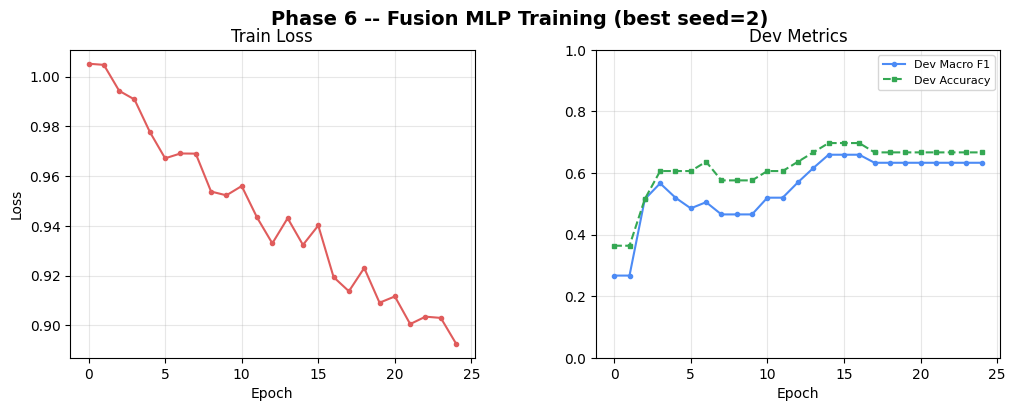

Plot saved to phase6_outputs/phase6_training_curves.png


In [13]:
best_history = seed_histories[best_seed_idx]

fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, wspace=0.3)
fig.suptitle(f"Phase 6 -- Fusion MLP Training (best seed={best_seed_idx})", fontsize=14, fontweight="bold")

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(best_history["epoch"], best_history["train_loss"], "o-", color="#e05c5c", markersize=3)
ax1.set_title("Train Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(best_history["epoch"], best_history["dev_macro_f1"], "o-", color="#4c8bf5", markersize=3, label="Dev Macro F1")
ax2.plot(best_history["epoch"], best_history["dev_accuracy"], "s--", color="#34a853", markersize=3, label="Dev Accuracy")
ax2.set_title("Dev Metrics"); ax2.set_xlabel("Epoch"); ax2.set_ylim(0, 1); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.savefig(os.path.join(OUTPUT_DIR, "phase6_training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to phase6_outputs/phase6_training_curves.png")

## Section 10: Save Results and Package for Download

In [14]:
torch.save({
    "model_state_dict": seed_models[best_seed_idx].state_dict(),
    "seed": best_seed_idx,
    "dev_macro_f1": seed_dev_f1s[best_seed_idx],
    "test_metrics": fused_metrics,
}, os.path.join(OUTPUT_DIR, "fusion_mlp_checkpoint.pt"))

with open(os.path.join(OUTPUT_DIR, "phase6_comprehensive_results.txt"), "w") as f:
    f.write("\n\n".join(report_lines))
    f.write("\n\nFINAL depressed_prob SOURCE FOR DEPLOYMENT: " + final_depression_source + "\n")

print("Saved fusion_mlp_checkpoint.pt and phase6_comprehensive_results.txt")

import shutil
from IPython.display import FileLink, display

zip_path = "/kaggle/working/phase6_outputs"
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
zip_full_path = zip_path + ".zip"
size_mb = os.path.getsize(zip_full_path) / (1024 * 1024)
print(f"\nZipped Phase 6 outputs to: {zip_full_path} ({size_mb:.2f} MB)")
display(FileLink(zip_full_path))

print("\nAll done. Download from the Output tab on Kaggle.")
print("\nFinal system output format:")
print("  condition_probs (5) -- from Phase 4 Head 1, unchanged")
print("  cause_probs (6)     -- from Phase 4 Head 2, unchanged")
print(f"  depressed_prob      -- from the '{final_depression_source}' model (this notebook's decision)")

Saved fusion_mlp_checkpoint.pt and phase6_comprehensive_results.txt

Zipped Phase 6 outputs to: /kaggle/working/phase6_outputs.zip (0.11 MB)


/kaggle/working/phase6_outputs.zip


All done. Download from the Output tab on Kaggle.

Final system output format:
  condition_probs (5) -- from Phase 4 Head 1, unchanged
  cause_probs (6)     -- from Phase 4 Head 2, unchanged
  depressed_prob      -- from the 'text' model (this notebook's decision)
